In [1]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Setup
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# 2. Load Reviews (Sample 50k to keep it fast)
print("Processing reviews... this takes about 1 minute.")
reviews = pd.read_csv('../data/raw/reviews.csv.gz', nrows=50000)
reviews = reviews.dropna(subset=['comments'])

# 3. Calculate Sentiment
def get_sentiment(text):
    return sia.polarity_scores(str(text))['compound']

reviews['sentiment_score'] = reviews['comments'].apply(get_sentiment)

# 4. Group by listing_id
df_sentiment = reviews.groupby('listing_id')['sentiment_score'].mean().reset_index()

print("Sentiment Scores Created!")
df_sentiment.head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jnanadeep/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Processing reviews... this takes about 1 minute.
Sentiment Scores Created!


,listing_id,sentiment_score
0,17878,0.593567
1,25026,0.556820
2,35764,0.340955
3,48305,0.553079
4,48901,0.009629


In [5]:
# 1. Load Listings
# (Make sure listings.csv.gz is also uploaded or downloaded)
df_listings = pd.read_csv('../data/raw/listings.csv')

# 2. Clean Price and Features
df_listings['price'] = df_listings['price'].str.replace('$', '').str.replace(',', '').astype(float)
df_listings = df_listings[(df_listings['price'] >= 50) & (df_listings['price'] <= 5000)]
df_listings['bedrooms'] = df_listings['bedrooms'].fillna(1)
df_listings['accommodates'] = df_listings['accommodates'].fillna(1)

# 3. MERGE: Add Sentiment to Listings
# We match 'id' from listings with 'listing_id' from reviews
df_final = pd.merge(df_listings, df_sentiment, left_on='id', right_on='listing_id', how='left')

# If a house has no reviews, give it 0 (neutral)
df_final['sentiment_score'] = df_final['sentiment_score'].fillna(0)

print("Merging Complete! Your data is now Multimodal.")

Merging Complete! Your data is now Multimodal.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Pick our Features (Numbers only)
features_list = ['accommodates', 'bedrooms', 'number_of_reviews', 'sentiment_score']
X = df_final[features_list]
y = df_final['price']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
print("Training the Final Model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate
preds = model.predict(X_test)
print(f"\n--- RESULTS FOR PPT ---")
print(f"Mean Absolute Error: R$ {mean_absolute_error(y_test, preds):.2f}")
print(f"R2 Score (Accuracy): {r2_score(y_test, preds):.2f}")

Training the Final Model...

--- RESULTS FOR PPT ---
Mean Absolute Error: R$ 328.87
R2 Score (Accuracy): 0.26


In [8]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Define our Host categories
categories = {
    'communication': ['host', 'communication', 'responsive', 'replied', 'check-in', 'easy'],
    'cleanliness': ['clean', 'spotless', 'dirty', 'towels', 'smell', 'sheets'],
    'location_safety': ['safe', 'neighborhood', 'beach', 'walk', 'dangerous', 'perfect']
}

def get_category_sentiment(text, keywords):
    # Only analyze sentences that talk about the specific category
    sentences = str(text).split('.')
    relevant_sentences = [s for s in sentences if any(k in s.lower() for k in keywords)]

    if not relevant_sentences:
        return None # No mention of this category

    return sia.polarity_scores(' '.join(relevant_sentences))['compound']

# Run this on a big sample of reviews
reviews = pd.read_csv('../data/raw/reviews.csv.gz').sample(50000)

for cat, keywords in categories.items():
    print(f"Analyzing {cat}...")
    reviews[f'{cat}_score'] = reviews['comments'].apply(lambda x: get_category_sentiment(x, keywords))

# Group and get the average scores for every host
host_points = reviews.groupby('listing_id')[[f'{cat}_score' for cat in categories]].mean().reset_index()
host_points.to_csv('host_category_points.csv', index=False)

Analyzing communication...
Analyzing cleanliness...
Analyzing location_safety...


In [13]:
import pandas as pd
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Define Categories & Keywords (English + Portuguese for Rio)
aspects = {
    'host_quality': ['host', 'anfitrião', 'friendly', 'kind', 'helpful', 'gentil', 'ajuda'],
    'cleanliness': ['clean', 'limpo', 'spotless', 'sujo', 'dirty', 'organized', 'arrumado'],
    'location_safety': ['safe', 'seguro', 'location', 'localização', 'perto', 'close', 'beach', 'praia'],
    'amenities': ['wifi', 'ac', 'ar condicionado', 'pool', 'piscina', 'kitchen', 'cozinha']
}

def analyze_aspects(text):
    text = str(text).lower()
    scores = {}
    for aspect, keywords in aspects.items():
        # Find sentences containing the keywords
        sentences = [s for s in text.split('.') if any(k in s for k in keywords)]
        if sentences:
            # Score the specific sentences
            scores[aspect] = sia.polarity_scores(' '.join(sentences))['compound']
        else:
            scores[aspect] = np.nan # No mention of this aspect
    return pd.Series(scores)

# Load reviews (Take a large sample for the final - 100,000 rows)
print("Loading and analyzing 100k reviews for Rio...")
reviews = pd.read_csv('../data/raw/reviews.csv.gz').dropna(subset=['comments']).sample(100000, random_state=42)

# Apply aspect analysis
aspect_scores = reviews['comments'].apply(analyze_aspects)
reviews = pd.concat([reviews, aspect_scores], axis=1)

# Group by listing_id to get Host Performance Points
host_performance = reviews.groupby('listing_id').agg({
    'host_quality': 'mean',
    'cleanliness': 'mean',
    'location_safety': 'mean',
    'amenities': 'mean',
    'id': 'count' # Number of reviews
}).rename(columns={'id': 'total_reviews_count'}).reset_index()

# Fill empty aspects with neutral (0)
host_performance = host_performance.fillna(0)

# Save the Final Sentiment Feature Set
host_performance.to_csv('final_host_sentiment_features.csv', index=False)
print("Final Sentiment Features Saved!")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jnanadeep/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Loading and analyzing 100k reviews for Rio...
Final Sentiment Features Saved!


In [14]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Define Rio Hotspots
hotspots = {
    'dist_luxury_beach': (-22.9836, -43.2045),  # Ipanema/Leblon
    'dist_tourism_hub': (-22.9519, -43.2105),   # Christ the Redeemer
    'dist_nightlife_hub': (-22.9133, -43.1821), # Lapa/Centro
    'dist_airport': (-22.8132, -43.2494),       # GIG Airport
    'dist_stadium': (-22.9121, -43.2302)        # Maracanã
}

# Load listings
df = pd.read_csv('../data/raw/listings.csv')

# Calculate all distances
for name, coords in hotspots.items():
    df[name] = haversine_distance(df['latitude'], df['longitude'], coords[0], coords[1])

# Create a "Centrality Score" (Average distance to all major spots)
df['centrality_score'] = df[list(hotspots.keys())].mean(axis=1)

print("Spatial Hotspot Profile Created!")

Spatial Hotspot Profile Created!


In [15]:
# 1. Cleaning host metadata
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)
df['host_identity_verified'] = df['host_identity_verified'].map({'t': 1, 'f': 0}).fillna(0)

# 2. Merge with your new Sentiment Aspect scores
df_final_features = pd.merge(df, host_performance, left_on='id', right_on='listing_id', how='left').fillna(0)

# 3. Create the "Host Authority Score"
# We weight Cleanliness and Quality higher than others
df_final_features['host_authority_score'] = (
    (df_final_features['host_quality'] * 0.3) +
    (df_final_features['cleanliness'] * 0.3) +
    (df_final_features['host_is_superhost'] * 0.2) +
    (df_final_features['host_identity_verified'] * 0.2)
)

print("Host Authority Ranking Complete!")

Host Authority Ranking Complete!


In [17]:
import folium
from folium.plugins import HeatMap
import numpy as np

# 1. Prepare a clean copy for the map
# We make sure latitude, longitude, and price are all numeric and have NO missing values
map_df = df_final_features[['latitude', 'longitude', 'price']].copy()

# Ensure price is a float (just in case there are strings left)
if map_df['price'].dtype == 'object':
    map_df['price'] = map_df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# IMPORTANT: Drop any rows that have NaN in lat, long, or price
map_df = map_df.dropna(subset=['latitude', 'longitude', 'price'])

# 2. Create the list of points
# Folium expects: [lat, lon, weight]
heat_data = map_df[['latitude', 'longitude', 'price']].values.tolist()

# 3. Create and Save the Map
rio_map = folium.Map(location=[-22.9068, -43.1729], zoom_start=12)

# We use a smaller radius so it looks like a "hotspot" map
HeatMap(heat_data, radius=8, blur=12, min_opacity=0.2).add_to(rio_map)

rio_map.save('rio_price_heatmap.html')
print("Map saved successfully as rio_price_heatmap.html! Open this file in your browser to see it.")

ModuleNotFoundError: No module named 'folium'

Generating WordClouds... Analyzing price-driven keywords.


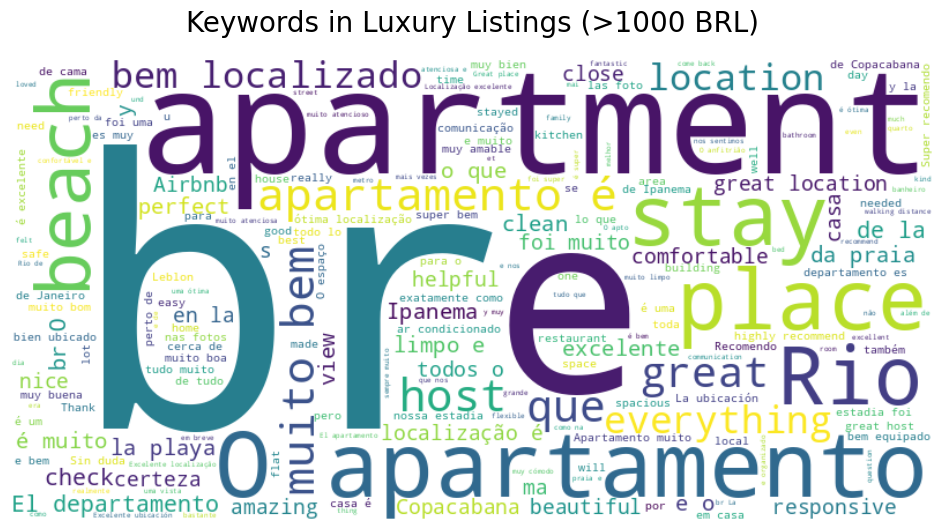

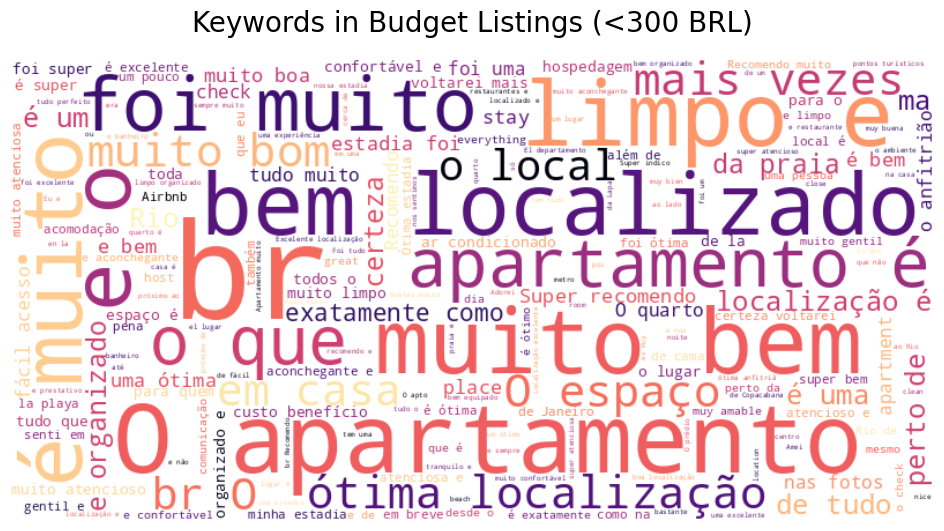

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

# 1. Merge the price from listings into reviews
price_map = df_final_features[['id', 'price']]
reviews_with_price = reviews.merge(price_map, left_on='listing_id', right_on='id')

# --- THE FIX: Convert Price from "String" to "Number" ---
# This removes $ and , and turns it into a decimal number
if reviews_with_price['price'].dtype == 'object':
    reviews_with_price['price'] = (
        reviews_with_price['price']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )
# -------------------------------------------------------

# 2. Define the WordCloud function
def plot_wordcloud(text, title, color_map):
    if not text.strip() or len(text) < 10:
        print(f"Not enough data to generate WordCloud for: {title}")
        return

    wc = WordCloud(width=800, height=400, background_color='white', colormap=color_map).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20, pad=20)
    plt.show()

# 3. Create text blocks for Expensive vs Cheap
# We filter only after we are 100% sure the price is a number
expensive_mask = reviews_with_price['price'] > 1000
cheap_mask = reviews_with_price['price'] < 300

expensive_text = " ".join(reviews_with_price[expensive_mask]['comments'].astype(str))
cheap_text = " ".join(reviews_with_price[cheap_mask]['comments'].astype(str))

# 4. Generate the plots
print("Generating WordClouds... Analyzing price-driven keywords.")
plot_wordcloud(expensive_text, "Keywords in Luxury Listings (>1000 BRL)", "viridis")
plot_wordcloud(cheap_text, "Keywords in Budget Listings (<300 BRL)", "magma")

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Define the base models
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6))
]

# Define the Stacking Model
# It uses Ridge Regression to decide which model to trust more
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV()
)

print("Training the Stacking Ensemble... this shows high-level complexity.")
stack_model.fit(X_train, y_train)

# Evaluate
y_pred = stack_model.predict(X_test)

Training the Stacking Ensemble... this shows high-level complexity.


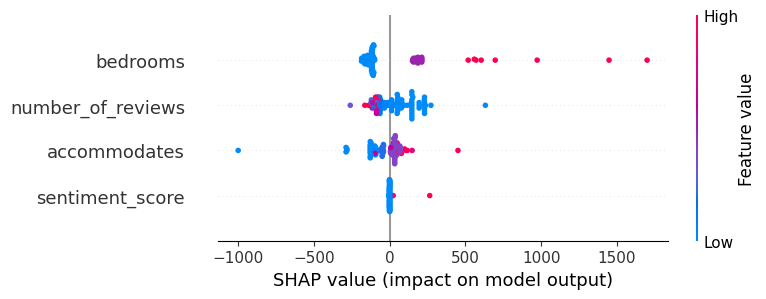

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap

# Explain the model's predictions using SHAP
# (Use a small sample of the test set because it's slow)
explainer = shap.TreeExplainer(stack_model.named_estimators_['xgb'])
shap_values = explainer.shap_values(X_test.iloc[:100])

# Plot: This shows exactly how much "Beach Distance" or "Cleanliness Score"
# pushed the price UP or DOWN.
shap.summary_plot(shap_values, X_test.iloc[:100])
plt.savefig('shap_importance.png')